In [125]:
import tkinter as tk
from tkinter import filedialog
import hyperspy.api as hs

In [126]:
# Create a function to select a file
def load_file():
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    file_path = filedialog.askopenfilename(
        title="Select a .hspy file",
        filetypes=[("All Files", "*.*"), ("Hyperspy Files", "*.hspy")]
    )

    if file_path:  # If a file is selected
        print("Selected file:", file_path)
        data = hs.load(file_path)
        print(data)
        return data  # Return loaded data

    return None  # If no file is selected

# Load the selected file
data = load_file()


Selected file: C:/Users/b1104371/OneDrive - Universität Salzburg/Research/Electrolyte variation/Charecterizations/TEM/250121_LiS-charged100/Charged100-Pre_0020.prz
<Signal2D, title: Charged100-Pre, dimensions: (|2048, 2048)>


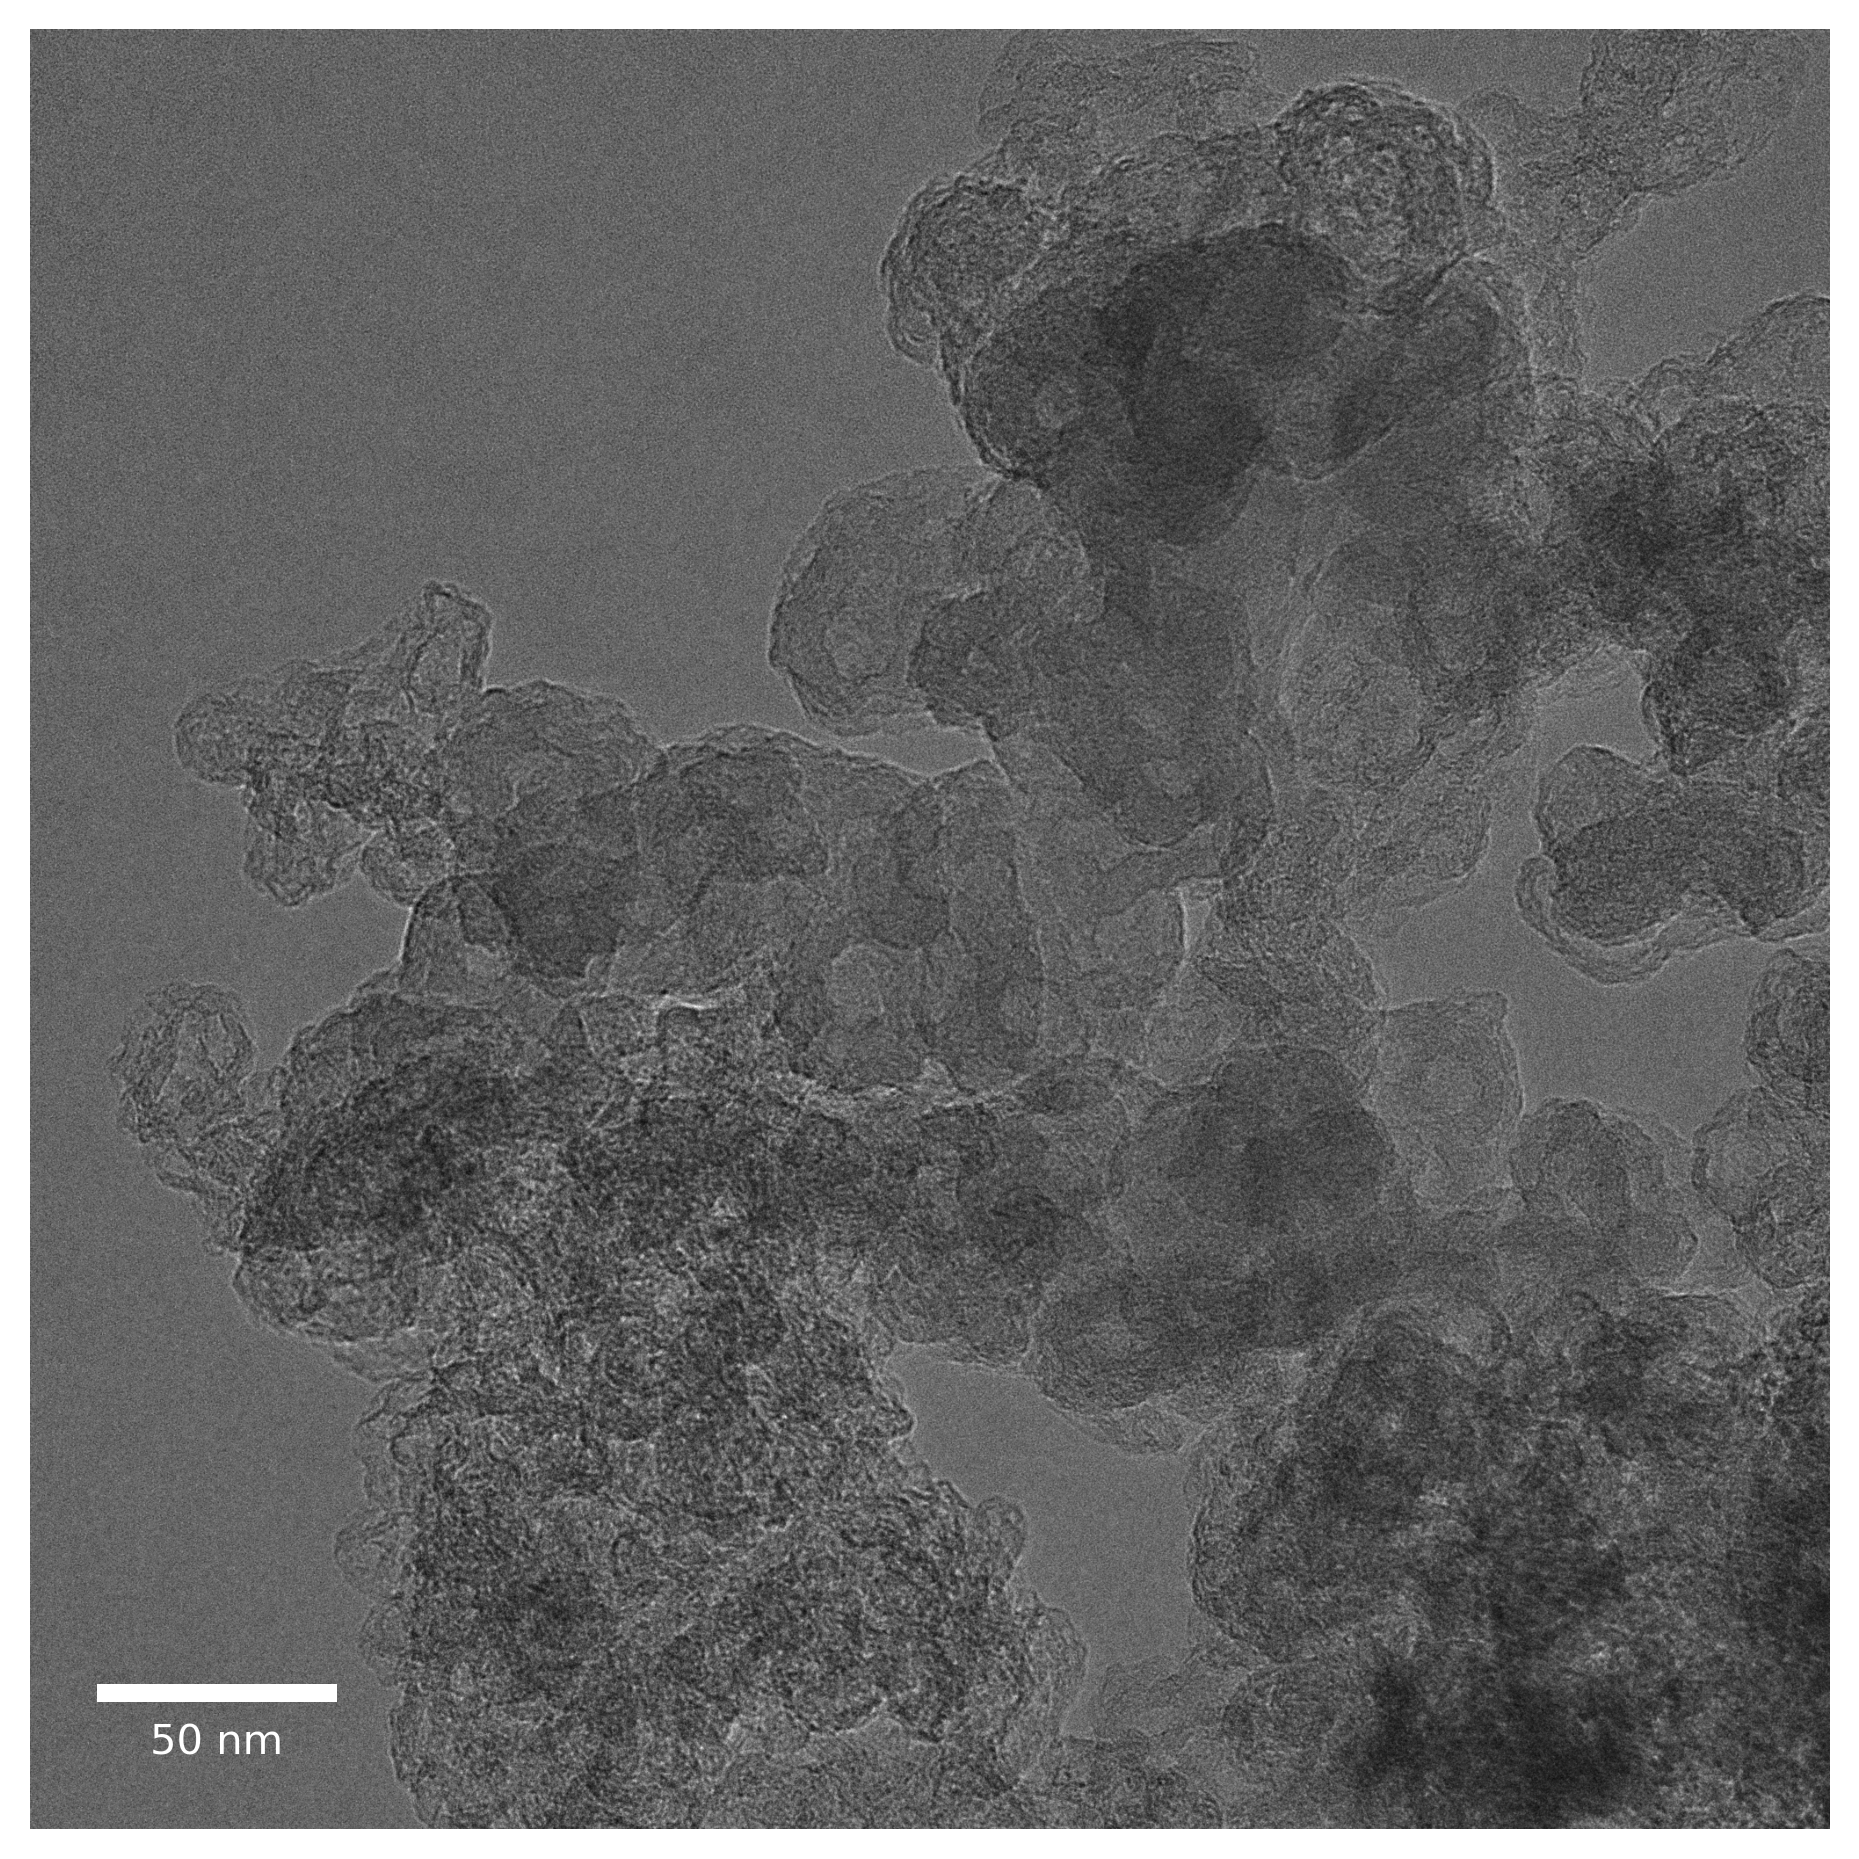

In [127]:
import hyperspy.api as hs
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar


# Get Pixel Size from Metadata (Stored in Meters)
pixel_size_m = data.axes_manager[0].scale  # This is in meters
pixel_size_nm = pixel_size_m * 1e9  # Convert meters to nanometers

# Create Figure & Plot Data Without Borders
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
fig.patch.set_alpha(0)  # Make figure background transparent
ax.set_xticks([])  # Remove X-axis
ax.set_yticks([])  # Remove Y-axis
ax.set_frame_on(False)  # Remove frame

# Remove unnecessary margins
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Plot the TEM image
ax.imshow(data.data, cmap="gray")

# Add Scale Bar inside the image with transparency
scalebar = ScaleBar(
    pixel_size_nm, "nm", 
    length_fraction=0.15,  # Reduce size slightly for better fit
    color="white",  # Scale bar color
    location="lower left",  # Move slightly inside
    scale_loc=None,  # No background box
    label_loc="bottom",  # Label at bottom
    frameon=False,  # No border/frame
    pad=1.5  # Moves scale bar slightly inward
)
ax.add_artist(scalebar)

# Show the final image with the scale bar
plt.show()


In [ ]:
import numpy as np

# Normalize data to range [0, 255] for better visibility
data_norm = (data.data - np.min(data.data)) / (np.max(data.data) - np.min(data.data))
data_norm = (data_norm * 255).astype(np.uint8)

import tifffile
tifffile.imwrite("test_normalized-2.tiff", data_norm)
